In [13]:
# load in the simulated metabolic data we want to plot 
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Check if pickle file exists, if so load it; otherwise read from clipboard and save
pickle_path = os.path.join('data', 'simulated_metabolics_data.pkl')

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print("Loaded data from pickle file")
else:
    df = pd.read_clipboard()
    print("Loaded data from clipboard")
    os.makedirs('data', exist_ok=True)
    df.to_pickle(pickle_path)
    print(f"Saved data to pickle: {pickle_path}")

print(df)

Loaded data from pickle file
      length    stiff  t = 0.608  t = 0.648  t = 0.6835  t = 0.7235
0     l = 25   k = 30  -1.416000  -2.404158    3.863729    6.492371
1     l = 25   k = 60  -4.348200  -6.202055    0.660192    5.088139
2     l = 25  k = 120  -8.967983  -9.977219   -2.769343    6.664285
3     l = 25  k = 180 -12.054056 -10.826377    1.271643   13.582603
4     l = 25  k = 240 -11.655233  -4.608546    8.814369   21.196126
5   l = 12.5   k = 30  -2.238976  -3.240697    2.741215    5.473406
6   l = 12.5   k = 60  -5.732230  -9.057465   -1.452853    3.613849
7   l = 12.5  k = 120 -11.150695 -11.715929   -1.447158    9.594033
8   l = 12.5  k = 180 -10.750583  -4.540953    8.131385   19.901930
9   l = 12.5  k = 240  -4.791325   7.825081   20.972055   33.637276
10  l = 37.5   k = 30  -0.435144  -0.668339    4.887977    8.266479
11  l = 37.5   k = 60  -2.507156  -3.919136    2.702713    5.013628
12  l = 37.5  k = 120  -6.673880  -9.607356   -1.076378    3.239467
13  l = 37.5  k = 1

In [17]:
# Create a plotting-focused copy and reshape to long format for efficient iteration

df_plot = df.copy()

# Assume first 2 columns are exotendon length/stiffness and remaining 4 are metabolic results
param_cols = list(df_plot.columns[:2])
metabolic_cols = list(df_plot.columns[2:])

if len(param_cols) != 2 or len(metabolic_cols) != 4:
    raise ValueError(
        f"Expected 6 columns total (2 params + 4 metabolic), got {len(df_plot.columns)}"
    )

df_plot = df_plot.rename(
    columns={
        param_cols[0]: "exotendon_length",
        param_cols[1]: "exotendon_stiffness",
    }
)

# Length and stiffness can be strings like "l = 25" / "k = 60", so extract numeric value first
for c in ["exotendon_length", "exotendon_stiffness"]:
    df_plot[c] = (
        df_plot[c].astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0]
    )

# Ensure numeric types where expected
for c in ["exotendon_length", "exotendon_stiffness"] + metabolic_cols:
    df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

# Keep rows with complete plotting data
df_plot = df_plot.dropna(subset=["exotendon_length", "exotendon_stiffness"] + metabolic_cols).copy()

# Long format: one metabolic cost per simulation time label
df_long = df_plot.melt(
    id_vars=["exotendon_length", "exotendon_stiffness"],
    value_vars=metabolic_cols,
    var_name="simulation_time_label",
    value_name="metabolic_cost",
)

# Infer numeric simulation time from column names if present (e.g., "0.5s", "t_50")
df_long["simulation_time_numeric"] = (
    df_long["simulation_time_label"].astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0]
)
df_long["simulation_time_numeric"] = pd.to_numeric(
    df_long["simulation_time_numeric"], errors="coerce"
)

label_order = (
    df_long[["simulation_time_label", "simulation_time_numeric"]]
    .drop_duplicates()
    .sort_values(["simulation_time_numeric", "simulation_time_label"], na_position="last")
    ["simulation_time_label"]
    .tolist()
)

df_long["simulation_time_label"] = pd.Categorical(
    df_long["simulation_time_label"], categories=label_order, ordered=True
)

# Map simulation time labels to manuscript-friendly relative percentages
sim_time_pct_labels = ["90%", "95%", "100%", "105%"]
sim_time_map = dict(zip(label_order, sim_time_pct_labels))
df_long["simulation_time_percent"] = (
    df_long["simulation_time_label"].astype(str).map(sim_time_map)
)

# Pre-group for fast subplot lookup by (stiffness, length)
grouped_results = {
    key: grp.sort_values("simulation_time_label").copy()
    for key, grp in df_long.groupby(
        ["exotendon_stiffness", "exotendon_length"], sort=True
    )
}

length_values = np.sort(df_long["exotendon_length"].unique())
stiffness_values = np.sort(df_long["exotendon_stiffness"].unique())

print(f"Unique lengths: {len(length_values)} -> {length_values}")
print(f"Unique stiffnesses: {len(stiffness_values)} -> {stiffness_values}")
print(f"Simulation-time mapping: {sim_time_map}")
print(df_long.head())

Unique lengths: 5 -> [ 6.3 12.5 25.  37.5 50. ]
Unique stiffnesses: 5 -> [ 30  60 120 180 240]
Simulation-time mapping: {'t = 0.608': '90%', 't = 0.648': '95%', 't = 0.6835': '100%', 't = 0.7235': '105%'}
   exotendon_length  exotendon_stiffness simulation_time_label  \
0              25.0                   30             t = 0.608   
1              25.0                   60             t = 0.608   
2              25.0                  120             t = 0.608   
3              25.0                  180             t = 0.608   
4              25.0                  240             t = 0.608   

   metabolic_cost  simulation_time_numeric simulation_time_percent  
0       -1.416000                    0.608                     90%  
1       -4.348200                    0.608                     90%  
2       -8.967983                    0.608                     90%  
3      -12.054056                    0.608                     90%  
4      -11.655233                    0.608           

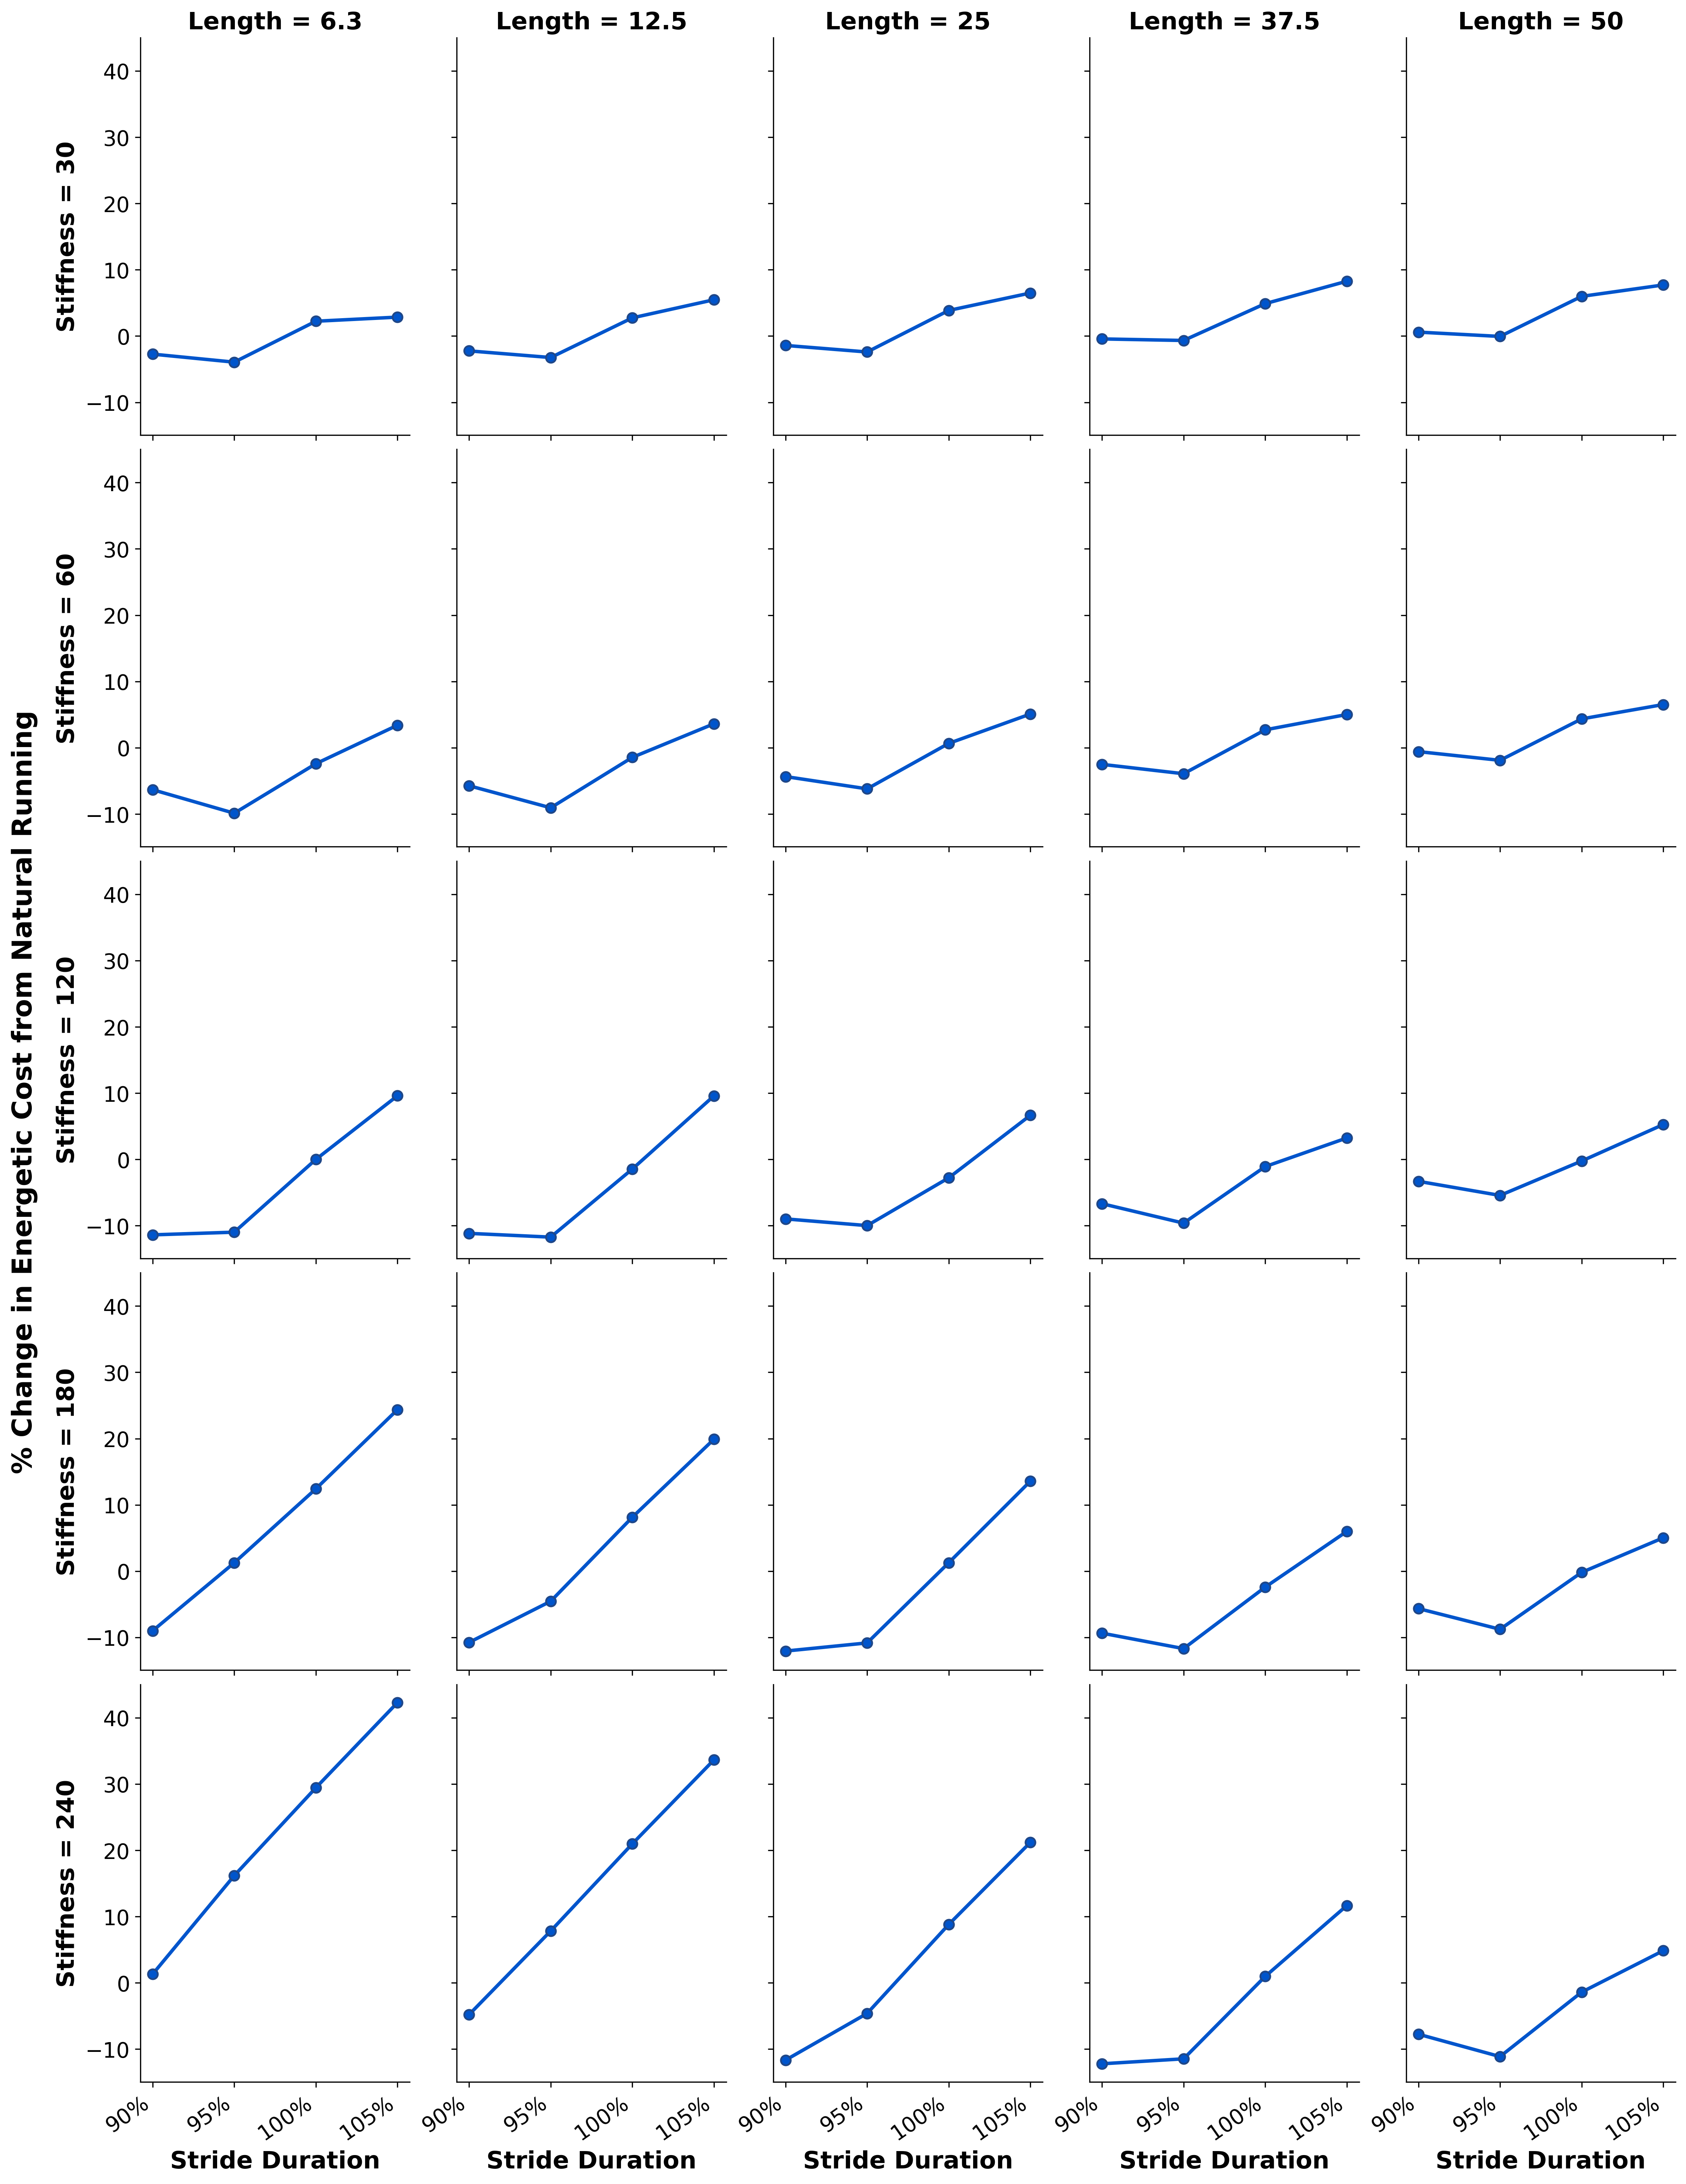

In [31]:
# 5x5 plot grid: rows = stiffness, columns = length; each panel = 4 simulation-time metabolic points

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

# Shared y-limits across all subplots with a small margin
ymin, ymax = df_long["metabolic_cost"].min(), df_long["metabolic_cost"].max()
y_pad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
y_lims = (ymin - y_pad, ymax + y_pad)

fig, axes = plt.subplots(
    nrows=len(stiffness_values),
    ncols=len(length_values),
    figsize=(15, 20),
    dpi=300,
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# Normalize axes indexing for edge cases
if len(stiffness_values) == 1 and len(length_values) == 1:
    axes = np.array([[axes]])
elif len(stiffness_values) == 1:
    axes = np.array([axes])
elif len(length_values) == 1:
    axes = np.array([[ax] for ax in axes])

xtick_labels = ["90%", "95%", "100%", "105%"]

for row_idx, stiffness in enumerate(stiffness_values):
    for col_idx, length in enumerate(length_values):
        ax = axes[row_idx, col_idx]
        subset = grouped_results.get((stiffness, length))

        if subset is None or subset.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
        else:
            y = subset["metabolic_cost"].to_numpy()
            x = np.arange(1, len(y) + 1)

            ax.plot(x, y, marker="o", linewidth=2.3, markersize=6.5, 
                    markeredgecolor="#1f4788", markeredgewidth=1.2, color="#0055CC")
            ax.set_xticks([1, 2, 3, 4])
            ax.set_xticklabels(xtick_labels, rotation=35, ha="right")

        ax.set_ylim(y_lims)

        # Cleaner axes for publication plots
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row_idx == 0:
            ax.set_title(f"Length = {length:g}", fontweight="bold", fontsize=16)

        if col_idx == 0:
            ax.set_ylabel(f"Stiffness = {stiffness:g}", fontweight="bold", fontsize=16)

        if row_idx == len(stiffness_values) - 1:
            ax.set_xlabel("Stride Duration", fontweight="bold", fontsize=16)

fig.supylabel("% Change in Energetic Cost from Natural Running", x=-0.025, fontsize=18, fontweight="bold")
plt.savefig("simulated_metabolics_grid.png", dpi=300, bbox_inches="tight")
plt.show()